In [147]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [148]:
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

nl43_seq_path = 'IN/data/in.nl43.reduce4.seq'
with open(nl43_seq_path, 'r') as f:
    nl43_seq = f.read().strip()

hxb2_seq_path = 'IN/data/in.hxb2.seq'
with open(hxb2_seq_path, 'r') as f:
    hxb2_seq = f.read().strip()

hxb2_reduced_seq = functions.unreduced_to_reduced_sequence(IN_redux,hxb2_seq)
# print("hxb2 reduced sequence:", hxb2_reduced_seq)

MJ4_seq_path = 'IN/data/in.mj4.seq'
with open(MJ4_seq_path, 'r') as f:
    mj4_seq = f.read().strip()

mj4_reduced_seq = functions.unreduced_to_reduced_sequence(IN_redux,mj4_seq)

dde 8.508784
dde 8.508782
dde 8.508787
dde 8.508787
IN_bars: [('consensus', np.float32(-5.7286787), np.float32(-4.553505), np.float32(-1.7733994)), ('NL4_3', np.float32(-6.7059155), np.float32(-4.577813), np.float32(-2.7749462)), ('HXB2', np.float32(-8.241928), np.float32(-0.30702782), np.float32(-0.040168762)), ('MJ4', np.float32(-8.241928), np.float32(-3.264598), np.float32(-0.040168762))]


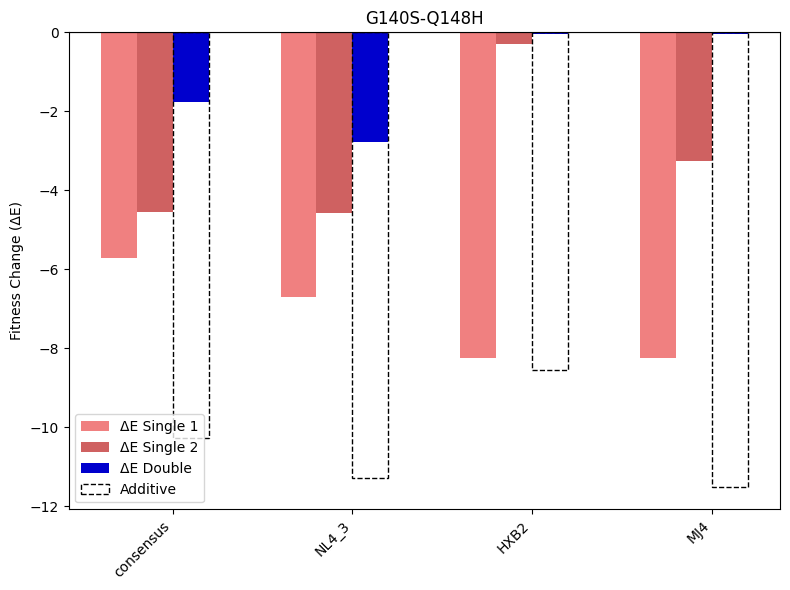

In [149]:
IN_pair = 'G140S-Q148H'
# IN_pair = 'Y143C-S230R'
# IN_pair = 'G140A-Q148K'
# IN_pair = 'G140S-Q148R'
# IN_pair = 'G140S-Q148K'

IN_HIV_subtypes = []
IN_HIV_subtypes.append(nl43_seq)


pair1, pair2 = functions.split_pairs(IN_pair)
p1_reduced = functions.unreduced_to_reduced(IN_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(IN_redux, pair2)

IN_bars = []

consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, IN_consensus_seq, IN_J, 1, 263)
IN_bars.insert(0, ('consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
print('dde', consensus_result[3])

nl43_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, nl43_seq, IN_J, 1, 263)
IN_bars.insert(1, ('NL4_3', nl43_result[0], nl43_result[1], nl43_result[2]))
print('dde', nl43_result[3])

hxb2_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, hxb2_reduced_seq, IN_J, 1, 263)
IN_bars.insert(2, ('HXB2', hxb2_result[0], hxb2_result[1], hxb2_result[2])) 
print('dde', hxb2_result[3])

mj4_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, mj4_reduced_seq, IN_J, 1, 263)
IN_bars.insert(3, ('MJ4', hxb2_result[0], mj4_result[1], hxb2_result[2])) 
print('dde', mj4_result[3])

print("IN_bars:", IN_bars)

plot.plot_epistatic_bar(IN_pair,IN_bars[:6])

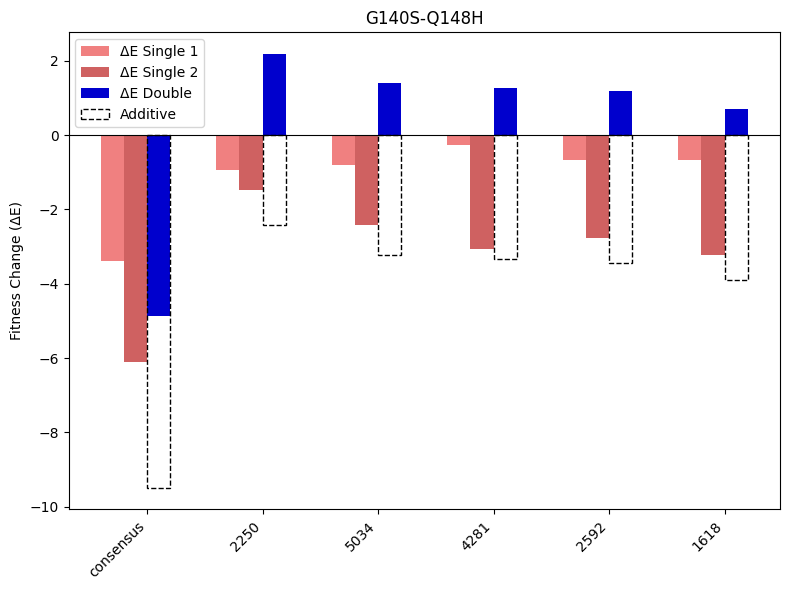

In [150]:
PR_pair = 'D30N-N88D'
# PR_pair = 'V32I-I47V'
# PR_pair = 'G48V-I54A'
# PR_pair = 'D30N-K45Q'
# PR_pair = 'I54A-V82A'

pair1, pair2 = functions.split_pairs(PR_pair)
p1_reduced = functions.unreduced_to_reduced(PR_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(PR_redux, pair2)

PR_bars = []
consensus_result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_consensus_seq, PR_J, 1, 99)

for PR_seq in PR_all_seq:
    # Debugging: Print inputs to the function

    result = functions.calculate_delta_delta_e(p1_reduced, p2_reduced, PR_seq, PR_J, 1, 99)
    
    # Check if the result is None
    if result is None:
        # print(f"Warning: result is None for sequence {IN_all_seq.index(IN_seq)}")
        continue  # Skip this sequence
    
    pair1_de, pair2_de, pair12_de, pair12_dde = result
    # print((IN_all_seq.index(IN_seq), pair1_de, pair2_de, pair12_dde))
    PR_bars.append((PR_all_seq.index(PR_seq), pair1_de, pair2_de, pair12_de))

PR_bars.sort(key=lambda x: x[3], reverse=True)
PR_bars.insert(0, ('consensus', consensus_result[0], consensus_result[1], consensus_result[2]))
# print("IN_bars:", IN_bars)
plot.plot_epistatic_bar(IN_pair,PR_bars[:6])

In [151]:
# print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[571]))
# print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[719]))
# print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[360]))
# print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[356]))
# print(functions.get_mutations_from_sequence(IN_consensus_seq,IN_all_seq[407]))

print(functions.get_mutations_from_sequence(IN_consensus_seq,nl43_seq))
print(functions.get_mutations_from_sequence(IN_consensus_seq,hxb2_reduced_seq))
print(functions.get_mutations_from_sequence(IN_consensus_seq,mj4_reduced_seq))

['A72D', 'C113D', 'A151B', 'C234A']
['C10B', 'A72D', 'C123A', 'C124A', 'A127B', 'C232D']
['A14B', 'B25A', 'C31A', 'B45A', 'A72D', 'A96B', 'A100C', 'A101B', 'D112C', 'C124A', 'D125A', 'D136B', 'B201A', 'C219A', 'A222C', 'C234D']
